# How do prices incorporate information? (Section 6)

Tests whether hourly price changes on Polymarket can be predicted from public information, as
Samuelson's fair-game result says they should not be. This notebook produces Table 6 (predictability
of hourly price changes), Figure 3 (autocorrelation of hourly price changes) and Figure 4
(distribution of market-by-market autocorrelation coefficients).

In [1]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pyfixest.estimation import feols

from common import OUTPUT_DIR

In [2]:
# only reads necessary columns so that we dont store unnecessary stuff in ram
# market id is in the index itself
panel = pd.read_parquet("../data/pipeline/panel.parquet", columns=["p", "hours_to_end"])

## Regression variables

- **`delta_p`**: the hourly price change in cents. A one cent change is a one percentage point change in
  the market's probability, and also the profit per share for someone who held through it, so the
  coefficients read directly as expected profit in cents per hour.
- **`p_lag`**: last hour's price, as a probability between 0 and 1. The price enters with a lag because
  $p_t$ already contains $\Delta p_t$, which would mechanically produce a positive coefficient.
- **`log_hours_to_end`**: log of one plus the hours until the market's *scheduled* end date. Traders know
  the scheduled date in advance, unlike the actual close, which depends on when the event resolves.
- **`past_end`**: a dummy for hours after the scheduled end date (`Overdue` in the paper), when markets
  may keep trading while the outcome is being confirmed.
- **`delta_p_lagged`, `delta_p_lagged2`, `delta_p_lagged3`**: the three previous hourly price changes.
- **`volatility`**: the standard deviation of hourly price changes over the previous 24 hours, in cents.

In [3]:
# a more memory efficient implementation
# doesnt store unnecessary copies of panel like the old one did
# and uses gc to clear memory as well

panel["log_hours_to_end"] = np.log1p(panel["hours_to_end"].clip(lower=0))
# dummy to take care of the impact of hours that are after the scheduled end date
panel["past_end"] = (panel["hours_to_end"] < 0).astype("int8")
panel.drop(columns=["hours_to_end"], inplace=True)

g = panel.groupby("market_id", observed=True) # groupby object
# multiplying by 100 makes 0.01 dollars into 1 cent, more interpretable
panel["delta_p"] = 100 * g["p"].diff()
# the price level stays a probability (0 to 1), so its coefficient is the difference in
# expected hourly drift (in cents) between a market at 100% and one at 0%
panel["p_lag"]   = g["p"].shift(1)

# these are already in cent terms since its built from delta_p which is in cents now
panel["delta_p_lagged"]  = g["delta_p"].shift(1)
panel["delta_p_lagged2"] = g["delta_p"].shift(2)
panel["delta_p_lagged3"] = g["delta_p"].shift(3)
# 24 hour rolling std dev
panel["volatility"] = (g["delta_p_lagged"].rolling(24, min_periods=5).std()
                       .reset_index(level=0, drop=True))

# turns panel itself into the regression frame, without keeping a second copy to save mem
panel.drop(columns=["p"], inplace=True)
panel.dropna(inplace=True)
panel.reset_index(inplace=True)          # market_id becomes a column for clustering
del g                                    # the groupby object keeps a reference to the data
gc.collect();

## Table 6: predictability of hourly price changes

We estimate equation (1) of the paper by pooled OLS:

$$\Delta p_t = \beta_0 + \beta_1 p_{t-1} + \beta_2 \log(1 + \max(\tau_t, 0)) + \beta_3 \text{Overdue}_t
+ \beta_4 \sigma_{t-1} + \sum_{k=1}^{3} \rho_k \Delta p_{t-k} + \varepsilon_t$$

Under the martingale hypothesis every coefficient is zero. Standard errors are clustered by market,
since price changes within a market are not independent. `pyfixest` is used with `lean=True` and
without copying the data, so the 42-million-row regression fits in memory.

In [4]:
# martingale w many lags
model = feols("delta_p ~ p_lag + log_hours_to_end + past_end"
            " + delta_p_lagged + delta_p_lagged2 + delta_p_lagged3 + volatility",
              data = panel,
              vcov={"CRV1": "market_id"},
              copy_data=False, store_data=False, lean=True)

model.summary(digits = 6)

###

Estimation:  OLS
Dep. var.: delta_p
sample: None = all
Inference:  CRV1
Observations:  42353513

| Coefficient      |   Estimate |   Std. Error |    t value |   Pr(>|t|) |      2.5% |     97.5% |
|:-----------------|-----------:|-------------:|-----------:|-----------:|----------:|----------:|
| Intercept        |   0.037389 |     0.001810 |  20.661885 |   0.000000 |  0.033842 |  0.040936 |
| p_lag            |  -0.046438 |     0.001344 | -34.548279 |   0.000000 | -0.049073 | -0.043803 |
| log_hours_to_end |  -0.003308 |     0.000239 | -13.838971 |   0.000000 | -0.003777 | -0.002840 |
| past_end         |   0.017722 |     0.004843 |   3.659576 |   0.000253 |  0.008230 |  0.027214 |
| delta_p_lagged   |  -0.142909 |     0.002129 | -67.133729 |   0.000000 | -0.147081 | -0.138737 |
| delta_p_lagged2  |  -0.050506 |     0.001253 | -40.292344 |   0.000000 | -0.052963 | -0.048049 |
| delta_p_lagged3  |  -0.014617 |     0.001252 | -11.676668 |   0.000000 | -0.017070 | -0.012163 |
| volat

With 42 million observations almost any coefficient is statistically significant, so the joint Wald
test rejecting that all coefficients are zero is expected. The paper's argument rests on the size of the
coefficients instead: the predictable part of hourly price changes is a fraction of a cent.

In [5]:
# annoying typechecking error
wald = model.wald_test()          # H0: Intercept = p_lag = ... = volatility = 0

print(f"""F_stat: {wald['statistic']}
p_value: {wald['pvalue']}
df_num: {model._dfn}
df_denom: {model._dfd}""")

F_stat: 977.1611469519527
p_value: 0.0
df_num: 8
df_denom: 48973


In [6]:
print(f"{panel['market_id'].nunique():,} markets, {len(panel):,} observations")

48,974 markets, 42,353,513 observations


## Figure 3: autocorrelation of hourly price changes

The correlation between each hour's price change and the change $k$ hours earlier, within markets,
for $k = 1, \dots, 24$. Prices that absorb news immediately would show no autocorrelation. Gradual
diffusion would show positive autocorrelation, and overreaction followed by correction negative.

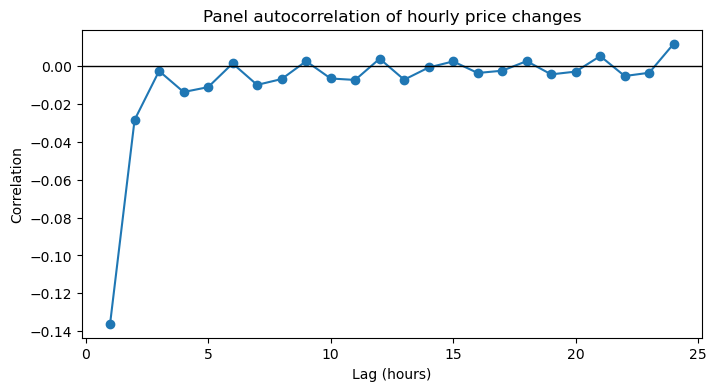

In [7]:
max_lag = 24

# plot the autocorrelation function
acf = []

for lag in range(1, max_lag + 1):
    # corr between delta p and delta_p_lagged for all lag values from 1 to 24
    corr = panel["delta_p"].corr(panel.groupby("market_id", observed=True)["delta_p"].shift(lag))
    acf.append(corr)

plt.figure(figsize=(8,4))
plt.plot(range(1, max_lag + 1), acf, marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.title("Panel autocorrelation of hourly price changes")
plt.savefig(OUTPUT_DIR / "acf.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 4: market-by-market autocorrelation

The pooled autocorrelation could hide very different markets that average out to something that looks
efficient. To check, we fit an AR(3) regression of price changes on their three lags separately for
every market with at least 30 hours of data, and look at the distribution of the coefficients. A single
peak means the pattern is common across markets rather than an artifact of pooling.

The coefficients are saved to `outputs/market_specific_ar3_coefficients.csv`. The histograms drop the
top and bottom 1% of each coefficient so a few extreme markets do not stretch the axes.

In [8]:
results = []

count = 0
for market_id, df in panel.groupby("market_id", observed=True):
    df = df.dropna(subset=[
        "delta_p",
        "delta_p_lagged",
        "delta_p_lagged2",
        "delta_p_lagged3"
    ])

    # Require a reasonable sample size
    if len(df) < 30:
        continue

    X = sm.add_constant(
        df[[
            "delta_p_lagged",
            "delta_p_lagged2",
            "delta_p_lagged3"
        ]]
    )

    y = df["delta_p"]

    try:
        model = sm.OLS(y, X).fit()

        results.append({
            "market_id": market_id,
            "beta1": model.params["delta_p_lagged"],
            "beta2": model.params["delta_p_lagged2"],
            "beta3": model.params["delta_p_lagged3"],
            "r2": model.rsquared,
            "n": len(df)
        })

    except Exception as e:
        print(f"{market_id}: {e}")
        break

betas = pd.DataFrame(results)

print(betas.describe())

betas.to_csv(OUTPUT_DIR / "market_specific_ar3_coefficients.csv", index=False)

c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/sel

              beta1         beta2         beta3            r2             n
count  46819.000000  46819.000000  46819.000000  46799.000000  46819.000000
mean      -0.092787     -0.307253     -0.029450      0.093265    903.740490
std        0.706366     45.200820      0.658825      0.121585   1473.825498
min      -28.979823  -9779.744114    -28.266535      0.000000     30.000000
25%       -0.218629     -0.161691     -0.086597      0.018287    163.000000
50%       -0.078585     -0.060495     -0.018213      0.048911    310.000000
75%        0.031816      0.005988      0.032470      0.117871    791.000000
max       98.884937     19.539546     71.963793      0.999898  14071.000000


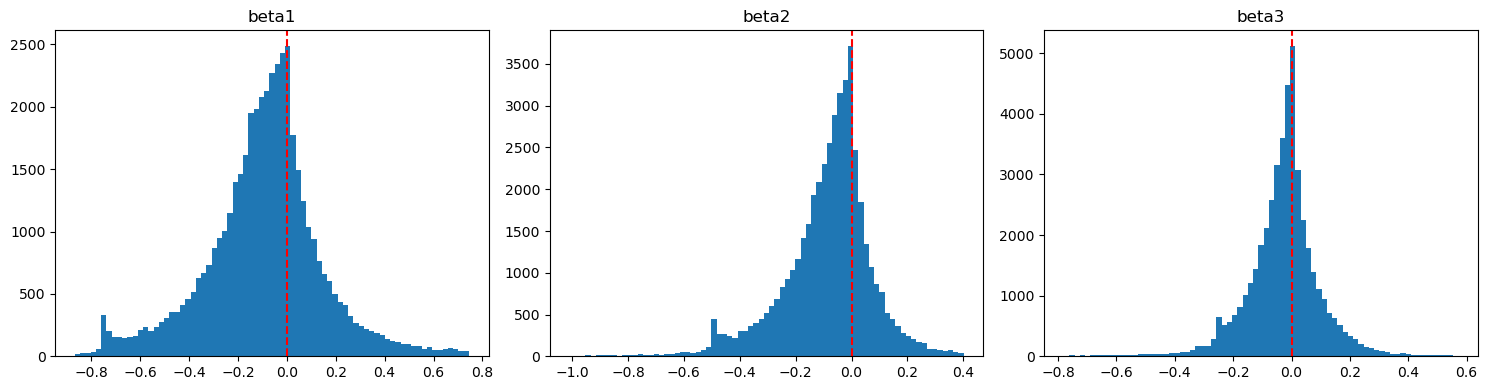

In [9]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

for ax, col in zip(axes, ["beta1","beta2","beta3"]):

    x = betas[col]

    lo = x.quantile(0.01)
    hi = x.quantile(0.99)

    x = x[(x >= lo) & (x <= hi)]

    ax.hist(x, bins=75)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(col)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "beta_distribution.png", dpi=300, bbox_inches="tight")

In [21]:
# markets near the pure-noise AR(3) pattern (-3/4, -1/2, -1/4)
target = np.array([-0.75, -0.5, -0.25])
dist = np.sqrt(((betas[["beta1", "beta2", "beta3"]] - target) ** 2).sum(axis=1))
betas["noise_like"] = dist < 0.15
print(f"{betas['noise_like'].sum():,} of {len(betas):,} markets ({betas['noise_like'].mean():.1%})")

# per-market price behaviour, from the reloaded panel
g = panel.groupby("market_id", observed=True)["p"]
stats = pd.DataFrame({
    "zero_share": g.apply(lambda x: (x.diff().dropna() == 0).mean()),   # hours with no price change
    "extreme_share": g.apply(lambda x: ((x < 0.05) | (x > 0.95)).mean()),  # hours priced near 0 or 1
    "mean_price": g.mean(),
})
stats.index = stats.index.astype(str)

betas = betas.join(stats, on=betas["market_id"].astype(str))
betas.groupby("noise_like")[["n", "zero_share", "extreme_share", "mean_price", "r2"]].median()

838 of 46,819 markets (1.8%)


,n,zero_share,extreme_share,mean_price,r2
noise_like,,,,,
False,312.0,0.579470,0.217647,0.186094,0.047491
True,165.0,0.618802,0.971947,0.021772,0.363373


## Appendix: Mincer–Zarnowitz calibration regressions

Never ended up using this. Thought it was a pretty cool idea but it was pretty much entirely focused on
calibration, and I couldn't see how I can tie this into the information story the paper tries to tell.

For each time-to-resolution bin, we take each market's last price in that bin and regress the outcome on
it: $Y = a + b\,p + e$. Perfectly calibrated prices give $a = 0$ and $b = 1$, which the Wald test checks.

The regression frame above no longer has prices or outcomes, so we reload the panel with the columns
this section needs and rebuild the time-to-resolution bins.

In [10]:
# the martingale section turned panel into the regression frame, so start fresh
del panel
gc.collect()

panel = pd.read_parquet("../data/pipeline/panel.parquet",
                        columns=["p", "price_bins", "yes_outcomes", "time_to_resolution"])

# equally splitting time bins doesnt make much sense, so these are
# "meaningful" intervals
time_edges = [0, 24, 48, 96, 168, 336, 720, 1440, 2880, np.inf]
time_labels = ["0-1 day", "1-2 days", "2-4 days", "4-7 days", "1-2 weeks",
               "2-4 weeks", "1-2 months", "2-4 months", ">4 months"]
panel["ttr_bin"] = pd.cut(panel["time_to_resolution"], bins=time_edges, labels=time_labels,
                          include_lowest=True, ordered=True)

In [11]:
def mincer_zarnowitz(df_og,
                    time_labels = [
                    "0-1 day",
                    "1-2 days",
                    "2-4 days",
                    "4-7 days",
                    "1-2 weeks",
                    "2-4 weeks",
                    "1-2 months",
                    "2-4 months",
                    ">4 months"]):

    # yes_outcomes was bool before which isnt accepted
    # so we'll make it 0/1
    df = df_og.copy()
    df["yes_outcomes"] = df["yes_outcomes"].astype(int)

    final_results = []
    final_tests = []

    # run a regression for every ttr bin given
    for time in time_labels:
        df_bin = df.loc[df.ttr_bin == time]

        # skip bins with no data in this cohort, rather than erroring
        # important for the cohorts
        if df_bin.empty:
            continue

        # we only look at the last observation for each market
        # so each market contributes only 1 observation to the regression
        df_bin = df_bin.groupby("market_id", observed=True).last()

        model = smf.ols('yes_outcomes ~ p', data = df_bin)
        market_ids = df_bin.index.get_level_values("market_id")

        results = model.fit(cov_type = "HC1")

        intercept = results.params["Intercept"]
        intercept_p = results.pvalues["Intercept"]

        slope = results.params["p"]
        slope_p = results.pvalues["p"]

        num_markets = market_ids.nunique()

        final = [intercept, intercept_p, slope, slope_p, num_markets]
        final_results.append(final)


        # testing null: intercept = 0 and slope = 1
        wald = results.wald_test("Intercept = 0, p = 1", use_f=True, scalar = True)
        F_stat = wald.statistic
        p_value = wald.pvalue
        df_num = wald.df_num
        df_denom = wald.df_denom

        tests = [F_stat, df_num, df_denom, p_value]
        final_tests.append(tests)

    # return a df instead of a 2d list
    results_table = pd.DataFrame(
    final_results,
    columns=[
        "Intercept",
        "Intercept p-value",
        "Slope",
        "Slope p-value",
        "Number of markets"
    ],
    index=time_labels[:len(final_results)]
    )

    tests_table = pd.DataFrame(
    final_tests,
    columns=[
        "F statistic",
        "df num",
        "df denom",
        "p-value",
    ],
    index=time_labels[:len(final_tests)]
    )

    return results_table, tests_table

### All markets

In [12]:
final_results, final_tests = mincer_zarnowitz(panel)

In [13]:
final_results

,Intercept,Intercept p-value,Slope,Slope p-value,Number of markets
0-1 day,-0.000385,4.807706e-02,1.001753,0.0,49643
1-2 days,0.017959,1.206254e-48,1.004655,0.0,48855
2-4 days,0.020006,2.923339e-51,1.002311,0.0,47149
4-7 days,0.019921,2.516265e-41,0.986820,0.0,43676
1-2 weeks,0.017523,2.144611e-25,0.945805,0.0,38297
2-4 weeks,0.004499,7.826550e-03,1.028130,0.0,20620
1-2 months,-0.006464,8.492873e-04,0.979421,0.0,13646
2-4 months,-0.007821,1.593753e-03,0.999775,0.0,8180
>4 months,-0.016120,8.559455e-07,0.948991,0.0,4780


In [14]:
final_tests

,F statistic,df num,df denom,p-value
0-1 day,20.741483,2.0,49641.0,9.904904e-10
1-2 days,114.812784,2.0,48853.0,1.795813e-50
2-4 days,121.788726,2.0,47147.0,1.753837e-53
4-7 days,91.374834,2.0,43674.0,2.507316e-40
1-2 weeks,75.066952,2.0,38295.0,2.901189e-33
2-4 weeks,13.085799,2.0,20618.0,2.091769e-06
1-2 months,9.846250,2.0,13644.0,5.332255e-05
2-4 months,5.321024,2.0,8178.0,4.904681e-03
>4 months,22.350220,2.0,4778.0,2.180451e-10


### Markets open for more than four months

Markets of different lifespans cover different kinds of events, so we repeat the regressions on the
cohort of long-lived markets only.

In [15]:
# creates a subset of the data that can be put into compute_decay_curve
def create_cohort(data, target_bin, time_edges = [0, 24, 48, 96, 168, 336, 720, 1440, 2880, np.inf],
                time_labels = [
                "0-1 day",
                "1-2 days",
                "2-4 days",
                "4-7 days",
                "1-2 weeks",
                "2-4 weeks",
                "1-2 months",
                "2-4 months",
                ">4 months"]):
    # for each market, find the furthest point it was ever tracked
    max_ttr_per_market = data.groupby("market_id", observed=True)["time_to_resolution"].max()

    # same time-binning as before
    market_lifespan_bin = pd.cut(
    max_ttr_per_market,
    bins=time_edges,
    labels=time_labels,
    include_lowest=True,
    ordered=True
    )

    # filter to find the bin that matches the target and select those from the input data
    matching_ids = market_lifespan_bin[market_lifespan_bin == target_bin].index
    cohort = data[data.index.get_level_values("market_id").isin(matching_ids)].copy()

    print(f"Cohort size: {cohort.index.get_level_values('market_id').nunique()} markets")
    print(f"Original sample: {data.index.get_level_values('market_id').nunique()} markets")

    return cohort

In [16]:
cohort_panel = create_cohort(panel, ">4 months") # to control for market size
cohort_results, cohort_tests = mincer_zarnowitz(cohort_panel)

Cohort size: 4780 markets
Original sample: 49661 markets


In [17]:
cohort_results

,Intercept,Intercept p-value,Slope,Slope p-value,Number of markets
0-1 day,-0.001169,2.159701e-14,1.003639,0.0,4779
1-2 days,-0.005213,1.586610e-04,1.035587,0.0,4778
2-4 days,-0.005132,3.791158e-04,1.047203,0.0,4778
4-7 days,-0.004343,6.343980e-03,1.054648,0.0,4778
1-2 weeks,-0.004518,1.048115e-02,1.054541,0.0,4779
2-4 weeks,-0.003818,4.591321e-02,1.052103,0.0,4780
1-2 months,-0.004772,3.403596e-02,1.054873,0.0,4780
2-4 months,-0.008333,1.605726e-03,1.039247,0.0,4780
>4 months,-0.016120,8.559455e-07,0.948991,0.0,4780


In [18]:
cohort_tests

,F statistic,df num,df denom,p-value
0-1 day,110.032273,2.0,4777.0,1.912555e-47
1-2 days,27.474795,2.0,4776.0,1.367628e-12
2-4 days,35.792750,2.0,4776.0,3.721782e-16
4-7 days,33.771767,2.0,4776.0,2.728049e-15
1-2 weeks,26.803520,2.0,4777.0,2.655887e-12
2-4 weeks,16.477034,2.0,4778.0,7.390591e-08
1-2 months,11.393072,2.0,4778.0,1.158278e-05
2-4 months,6.751416,2.0,4778.0,1.180410e-03
>4 months,22.350220,2.0,4778.0,2.180451e-10


### Calibration plot

The share of markets that resolved Yes against the average price, in each of the 20 price bins.
Points on the dashed 45-degree line are perfectly calibrated.

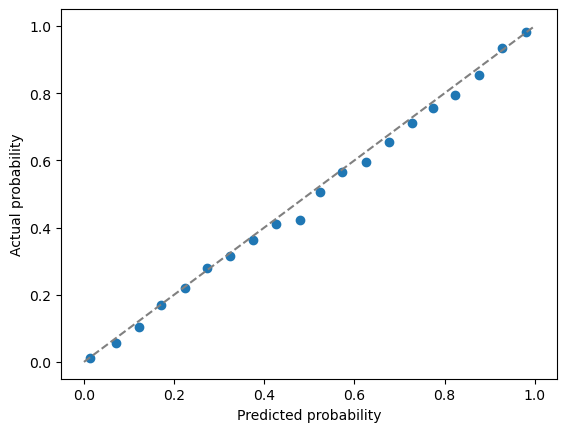

In [19]:
# same aggregation that we've been doing, but yes_rate, pred and n are now column names
df = panel.groupby("price_bins", observed=True).agg(
    yes_rate=("yes_outcomes", "mean"),
    pred=("p", "mean"),
    n=("p", "size"))

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.scatter(df["pred"], df["yes_rate"])
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.show()